# Desarrollo algoritmos para datos Yahoo! Music

Alumnos:
*   Alonso Casanova
*   Bruno Cerda


## Librerías

In [1]:
# Entorno se reinicia, no hay que volver a ejecutar

!pip uninstall -y numpy
!pip install numpy==1.26

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 67.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
shap 0.51.0 requires nump

In [1]:
!pip install scikit-surprise --no-build-isolation --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2708553 sha256=d12ccf1c0a0fd5c5b7d43a0d658bfdb06ba3d7a95f57495349836a259ca16858
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


In [2]:
import surprise
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from surprise.model_selection import PredefinedKFold
from surprise import BaselineOnly, Dataset, Reader,  NormalPredictor, accuracy

## Datos

In [3]:
!unzip OneDrive_2026-03-25.zip
!mv -f Datasets\ Tarea\ \(p├║blico\) Datos

Archive:  OneDrive_2026-03-25.zip
 extracting: Datasets Tarea (p├║blico)/competicion_ranking.json  
 extracting: Datasets Tarea (p├║blico)/competicion_rating.txt  
 extracting: Datasets Tarea (p├║blico)/wikimedia_image_embeddings.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_item_id_to_idx.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_train.csv  
 extracting: Datasets Tarea (p├║blico)/wikimedia_validation.csv  
 extracting: Datasets Tarea (p├║blico)/ydata_artists.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_train.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_val.txt  


In [4]:
yahoo_train = pd.read_csv("Datos/ydata_train.txt", sep="\t", header=None)
yahoo_train.columns = ["user_id", "artist_id", "rating"]
yahoo_train['rating'] = yahoo_train['rating'].replace(255, 0)

yahoo_validation = pd.read_csv("Datos/ydata_val.txt", sep="\t", header=None)
yahoo_validation.columns = ["user_id", "artist_id", "rating"]
yahoo_validation['rating'] = yahoo_validation['rating'].replace(255, 0)

# 1. Predicción Ratings

## 1.1 User-based collaborative filtering

In [5]:
reader = surprise.Reader(line_format='user item rating', rating_scale=(0,100))

# Codigo documentacion
train_data = Dataset.load_from_df(yahoo_train[["user_id", "artist_id", "rating"]], reader)
train_data = train_data.build_full_trainset()

validation_data = Dataset.load_from_df(yahoo_validation[["user_id", "artist_id", "rating"]], reader)
validation_data = validation_data.build_full_trainset()

In [6]:
k_values = [2, 10, 20, 30, 40, 50]
testset = validation_data.build_testset()

rmse_set = []
mae_set = []
for k in k_values:
  myUserKnn = surprise.KNNBasic(k=k, sim_options={'name': f'pearson', 'user_based': True})
  # Se entrena con set de entrenamiento
  myUserKnn.fit(train_data)
  # Se evalua con set de validacion
  predictions = myUserKnn.test(testset)

  rmse_set.append(accuracy.rmse(predictions))
  mae_set.append(accuracy.mae(predictions))

min_rmse_user_based_cf = min(np.array(rmse_set))
min_mae_user_based_cf = min(np.array(mae_set))

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 29.3066
MAE:  17.2600
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 26.3436
MAE:  17.9512
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 26.6685
MAE:  19.4021
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 27.1455
MAE:  20.4454
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 27.5503
MAE:  21.1800
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 27.8514
MAE:  21.6821


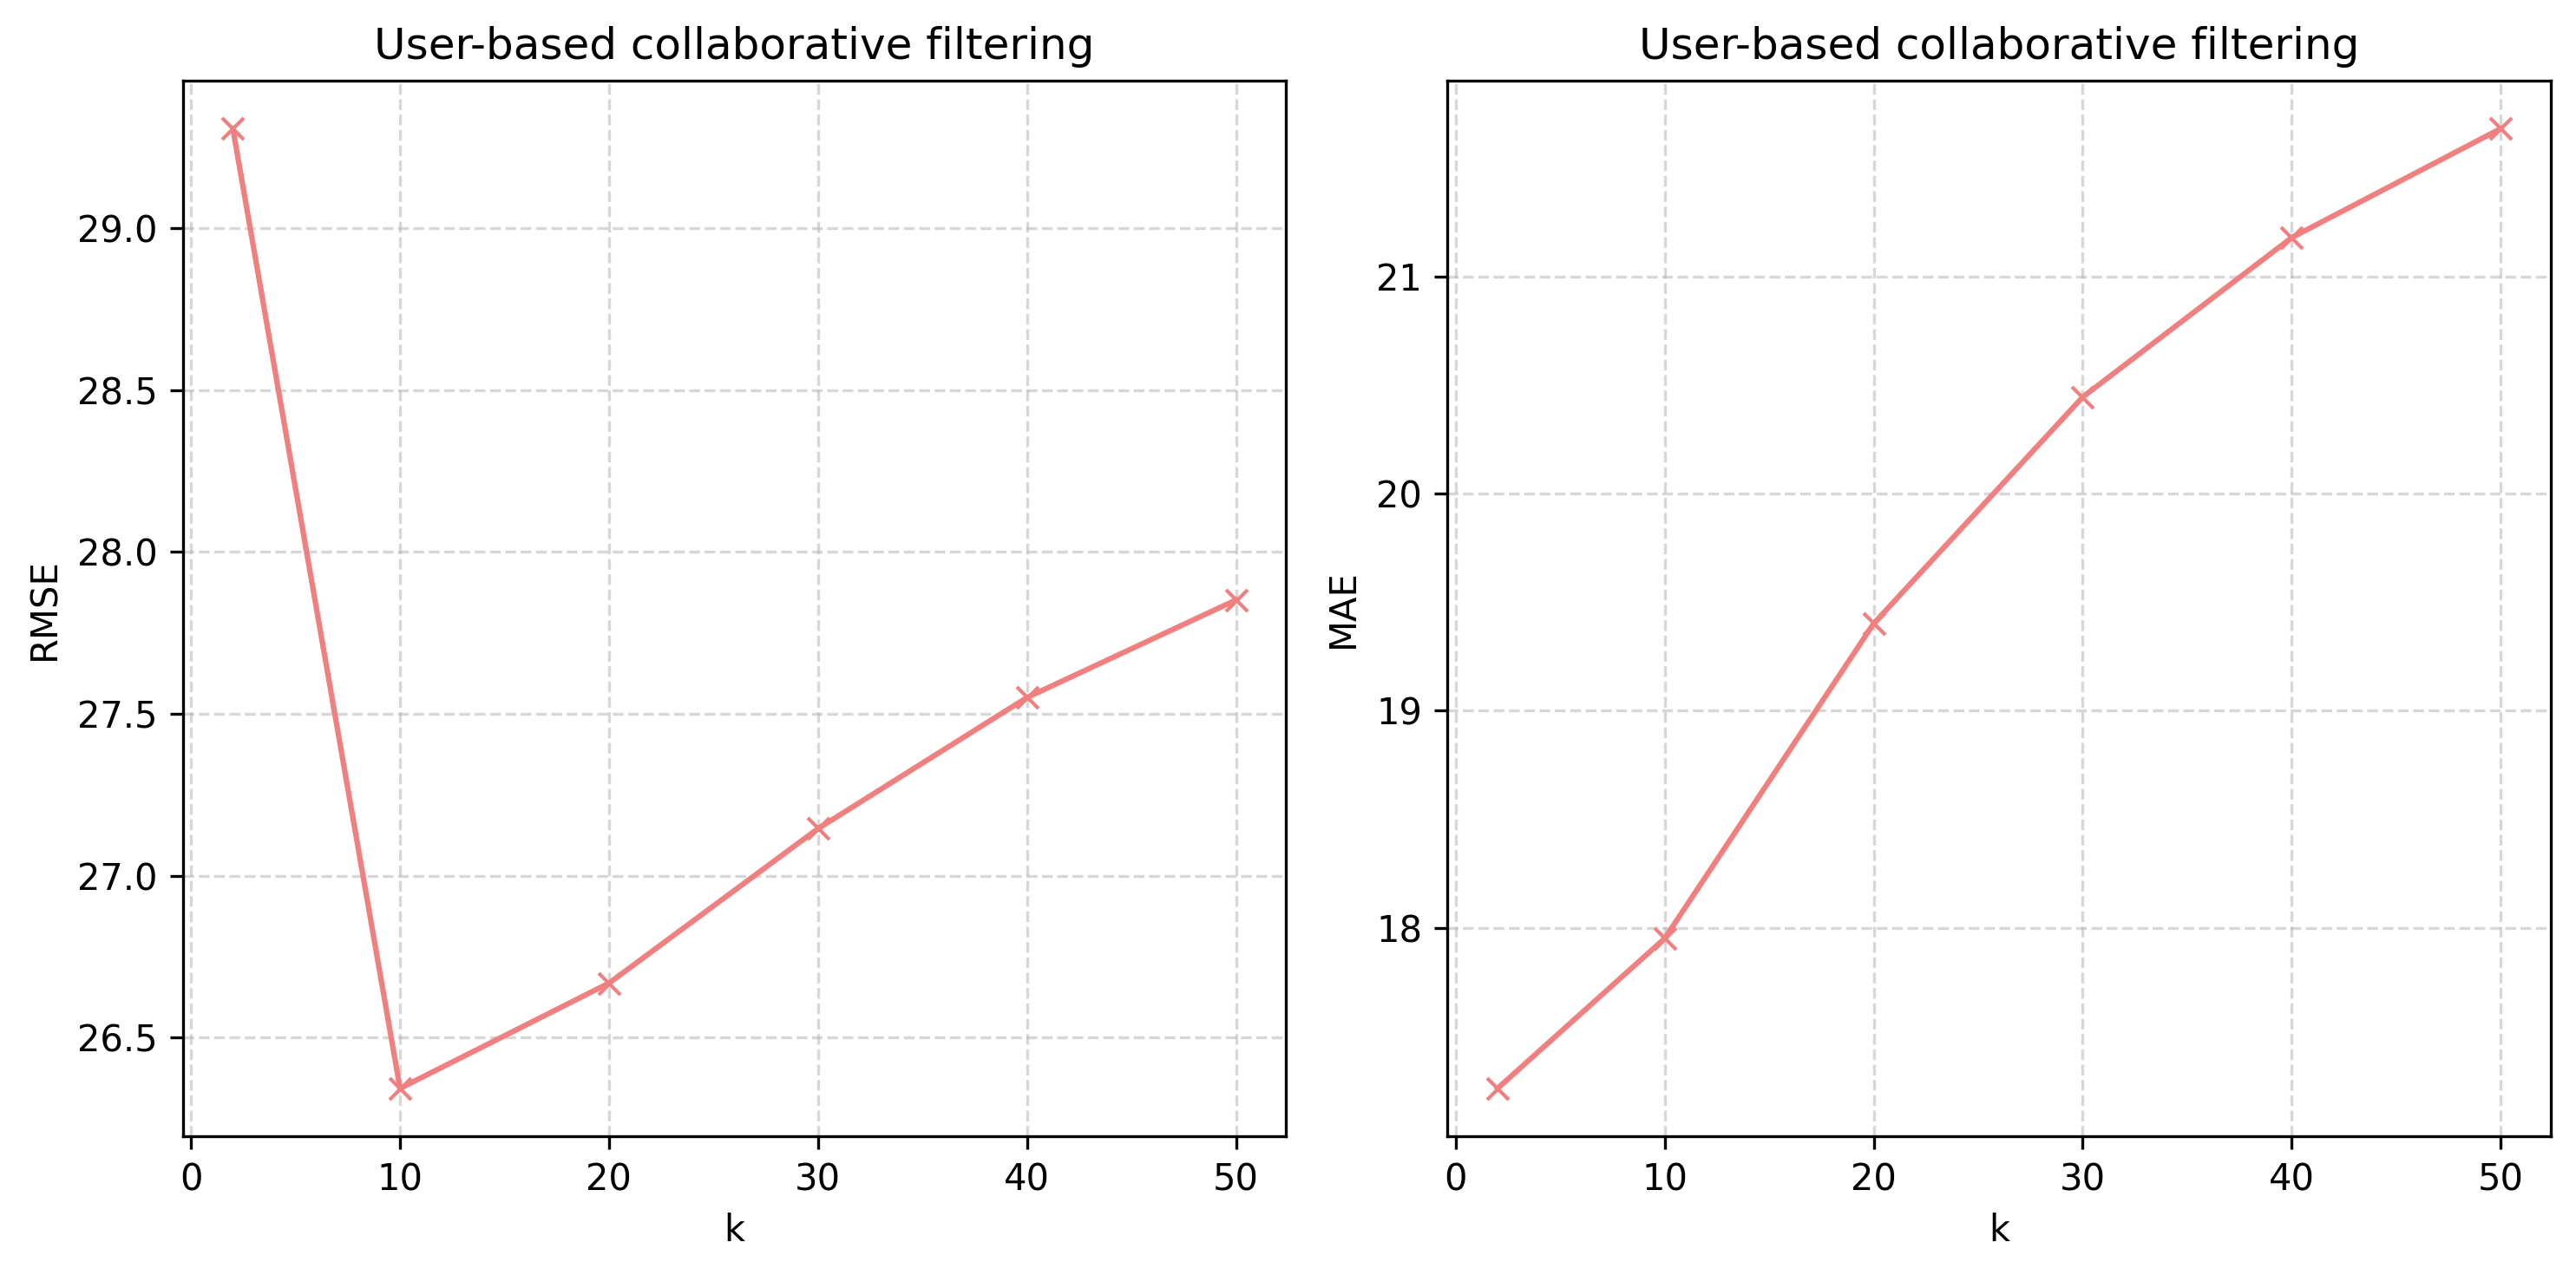

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

axes[0].plot(k_values, rmse_set, marker='x', color='lightcoral')
axes[0].set_title('User-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_values, mae_set, marker='x', color='lightcoral')
axes[1].set_title('User-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('MAE')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('user-based-filter-sens.jpeg')
plt.show()

## 1.2 Item-based collaborative filtering

In [10]:
k_values = [2, 10, 20, 30, 40, 50]
testset = validation_data.build_testset()

item_rmse_set = []
item_mae_set = []
for k in k_values:
  myUserKnn = surprise.KNNBasic(k=k, sim_options={'name': f'pearson', 'user_based': False})
  # Se entrena con set de entrenamiento
  myUserKnn.fit(train_data)
  # Se evalua con set de validacion
  predictions = myUserKnn.test(testset)

  item_rmse_set.append(accuracy.rmse(predictions))
  item_mae_set.append(accuracy.mae(predictions))

min_rmse_item_based_cf = min(np.array(item_rmse_set))
min_mae_item_based_cf = min(np.array(item_mae_set))

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 25.7522
MAE:  13.2712
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 22.5316
MAE:  12.4023
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 22.0165
MAE:  12.3880
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 21.8684
MAE:  12.4731
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 21.8026
MAE:  12.5731
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 21.7932
MAE:  12.6838


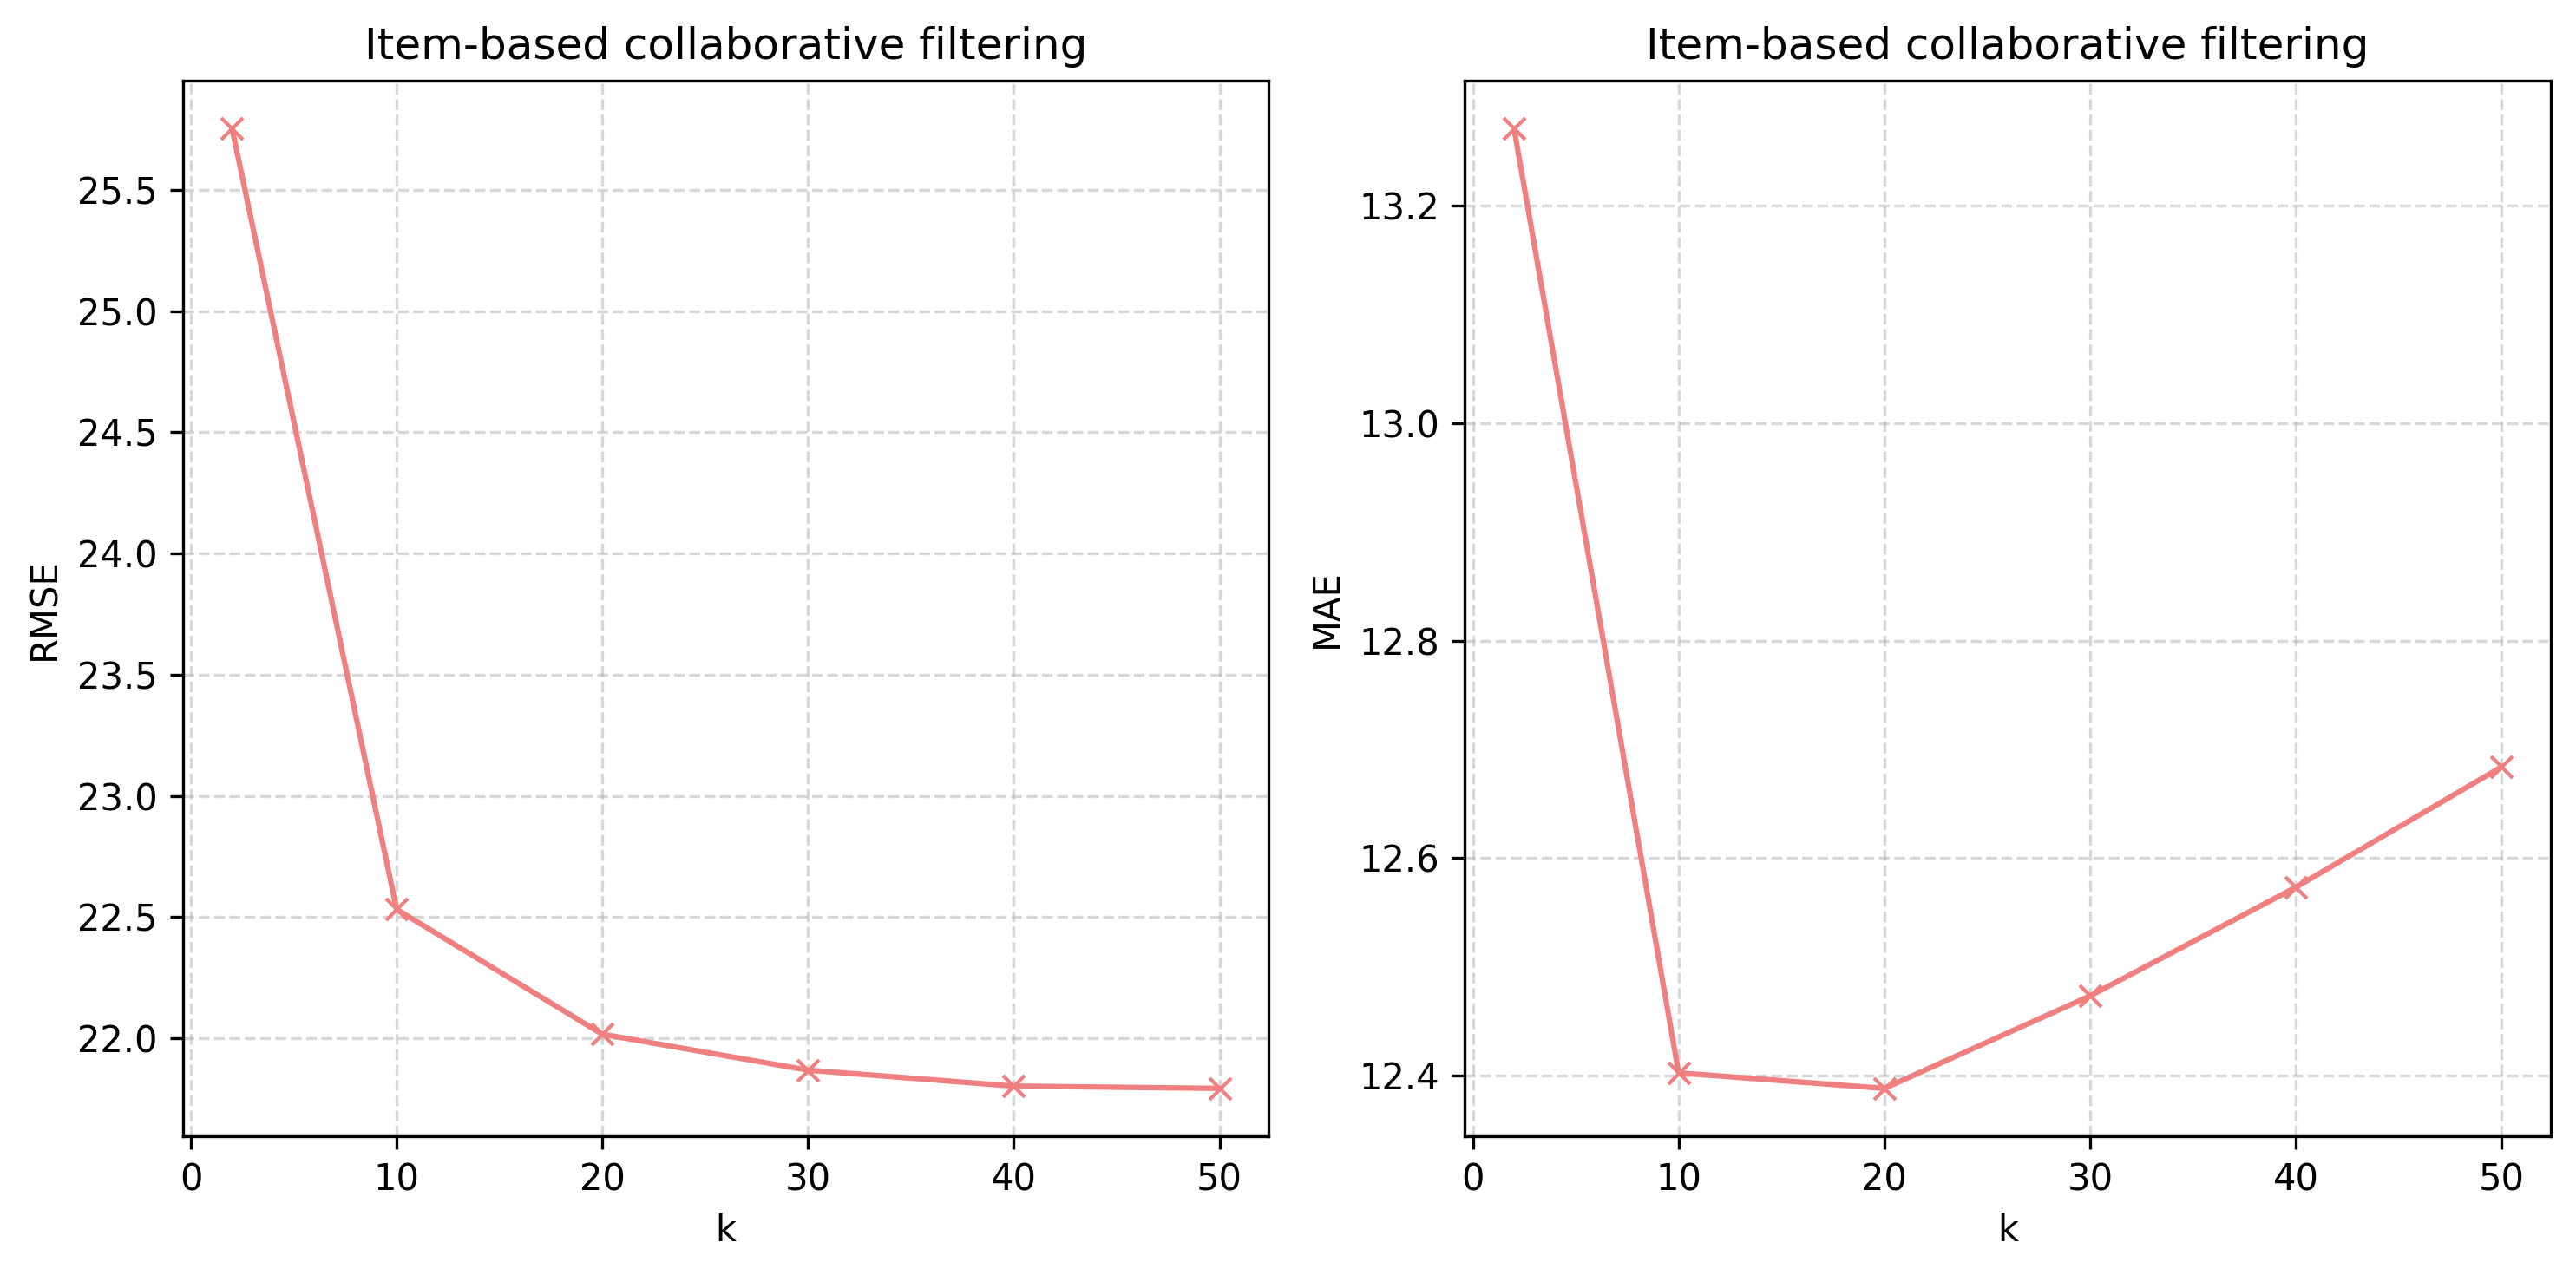

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

axes[0].plot(k_values, item_rmse_set, marker='x', color='lightcoral')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_values, item_mae_set, marker='x', color='lightcoral')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('MAE')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('item-based-filter-sens.jpeg')
plt.show()

## 1.3 FunkSVD

In [14]:
# En la documentacion hacen referencia a FunkSVD
from surprise.prediction_algorithms.matrix_factorization import SVD

n_factors = [3, 25, 50, 75, 100]
testset = validation_data.build_testset()

funk_svd_rmse_set = []
funk_svd_mae_set = []
for factor in n_factors:
  svd_model = SVD(n_factors=factor, n_epochs=20)
  # Se entrena con set de entrenamiento
  svd_model.fit(train_data)
  # Se evalua con set de validacion
  predictions = svd_model.test(testset)

  funk_svd_rmse_set.append(accuracy.rmse(predictions))
  funk_svd_mae_set.append(accuracy.mae(predictions))

min_rmse_funk_svd_cf = min(np.array(funk_svd_rmse_set))
min_mae_funk_svd_cf = min(np.array(funk_svd_mae_set))

RMSE: 20.7819
MAE:  12.8964
RMSE: 22.5440
MAE:  13.9892
RMSE: 87.0226
MAE:  81.4953
RMSE: 87.0226
MAE:  81.4953
RMSE: 87.0226
MAE:  81.4953


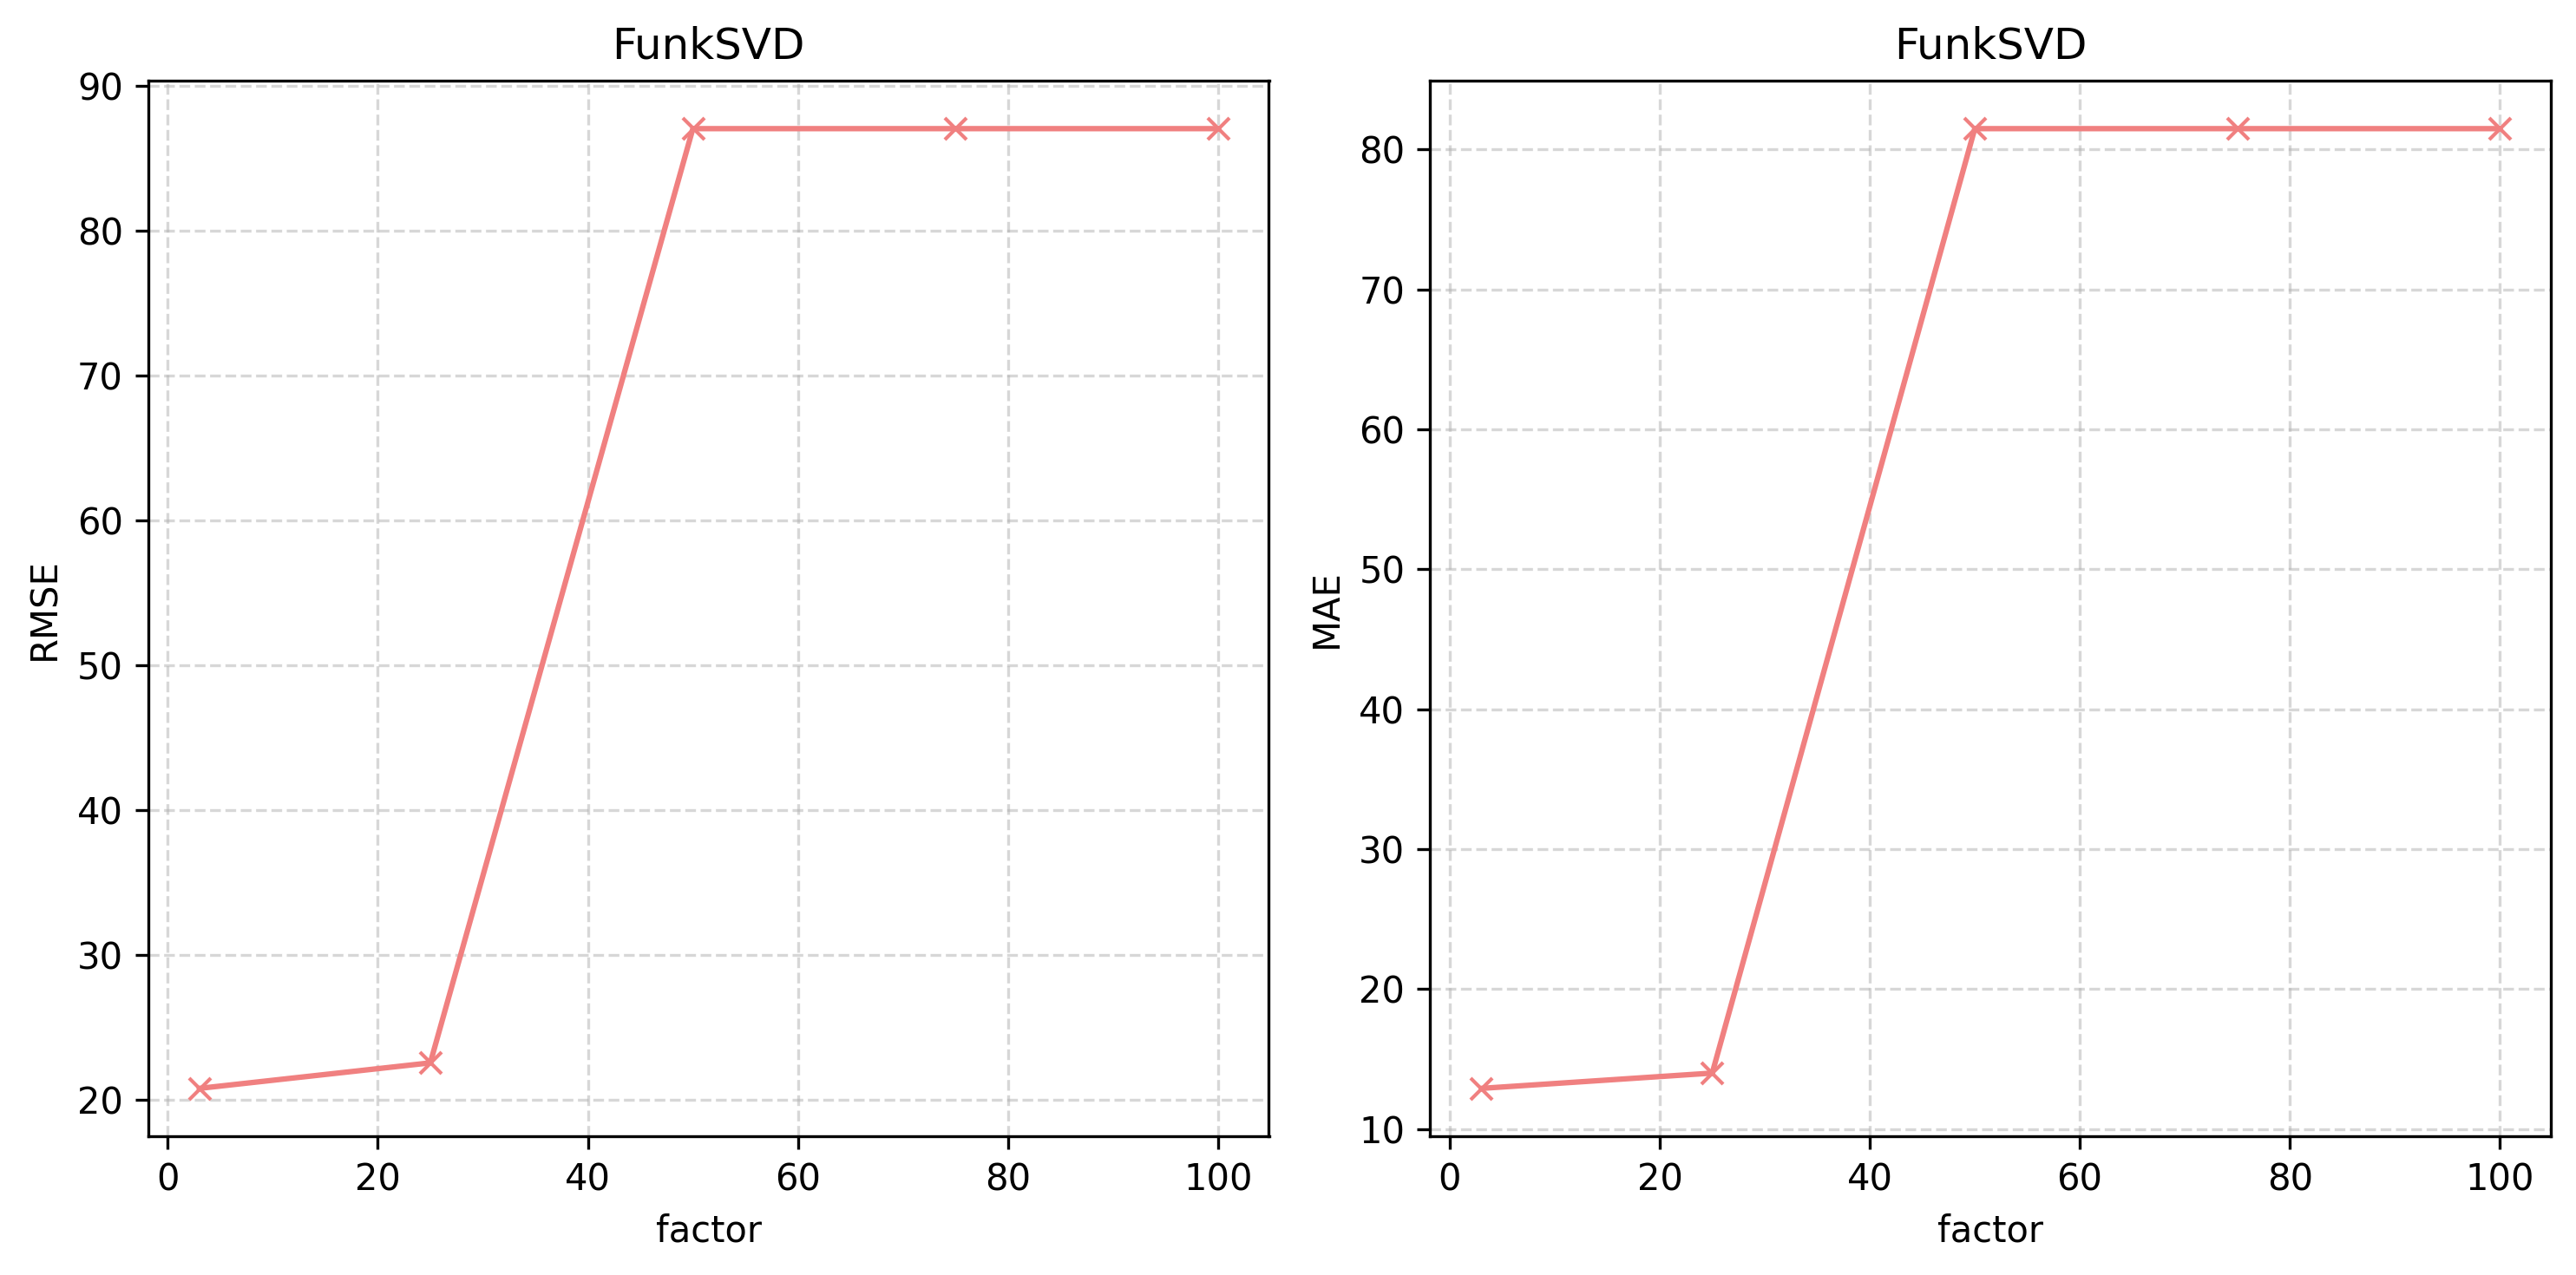

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

axes[0].plot(n_factors, funk_svd_rmse_set, marker='x', color='lightcoral')
axes[0].set_title('FunkSVD')
axes[0].set_xlabel('factor')
axes[0].set_ylabel('RMSE')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(n_factors, funk_svd_mae_set, marker='x', color='lightcoral')
axes[1].set_title('FunkSVD')
axes[1].set_xlabel('factor')
axes[1].set_ylabel('MAE')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('funk-svd-sens.jpeg')
plt.show()

## 1.4 SVD++ (Opcional)

In [18]:
# Completar

# 2. Listas de recomendación

In [19]:
!pip install pyreclab --upgrade
import pyreclab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 13.8 MB/s eta 0:00:00


In [20]:
N = 10

In [21]:
yahoo_artists = pd.read_csv("Datos/ydata_artists.txt", sep="\t", header=None)
yahoo_artists.columns = ["artist_id", "artist_name", "genre"]

In [22]:
# Codigo para evaluar métricas
import numpy as np

def recall_at_k(recs, gt, k):
    recalls = []
    for u in gt:
        if u not in recs:
            continue

        top_k = recs[u][:k]
        relevant = gt[u]

        if len(relevant) == 0:
            continue

        hits = len(set(top_k) & relevant)
        recalls.append(hits / len(relevant))

    return np.mean(recalls)


def ndcg_at_k(recs, gt, k):
    def dcg(rel):
        return sum([rel[i] / np.log2(i + 2) for i in range(len(rel))])

    ndcgs = []
    for u in gt:
        if u not in recs:
            continue

        top_k = recs[u][:k]
        relevant = gt[u]

        if len(relevant) == 0:
            continue

        rel = [1 if item in relevant else 0 for item in top_k]
        dcg_val = dcg(rel)

        num_relevant = len(relevant)
        ideal_rel = [1] * min(num_relevant, k) + [0] * (k - min(num_relevant, k))
        idcg_val = dcg(ideal_rel)

        ndcgs.append(dcg_val / idcg_val)

    return np.mean(ndcgs)

# def dcg_at_k(r, k):
#     r = np.asarray(r)[:k]
#     if r.size:
#         return np.sum(np.subtract(np.power(2, r), 1) / np.log2(np.arange(2, r.size + 2)))
#     return 0.


# def ndcg_at_k(r, k):
#     idcg = dcg_at_k(sorted(r, reverse=True), k)

#     if not idcg:
#         return 0.
#     return dcg_at_k(r, k) / idcg

def map_at_k(recs, gt, k):
    aps = []

    for u in gt:
        if u not in recs:
            continue

        top_k = recs[u][:k]
        relevant = gt[u]

        if len(relevant) == 0:
            continue

        hits = 0
        sum_precisions = 0

        for i, item in enumerate(top_k):
            if item in relevant:
                hits += 1
                sum_precisions += hits / (i + 1)

        aps.append(sum_precisions / len(relevant))

    return np.mean(aps)

In [23]:
ground_truth = {}

threshold = 50
val_relevantes = yahoo_validation[yahoo_validation['rating'] >= threshold]

for _, row in val_relevantes.iterrows():
    user = row['user_id']
    item = row['artist_id']

    if user not in ground_truth:
        ground_truth[user] = set()

    ground_truth[user].add(item)

In [24]:
# Este código es de un práctico
def get_top_n(predictions, n=10):
    """Devuelve las N-mejores recomendaciones para cada usuario de un set de predicción.

    Args:
        predictions(lista de objetos Prediction): La lista de predicción obtenida del método test.
        n(int): El número de recomendaciónes por usuario

    Returns:
    Un diccionario donde las llaves son ids de usuario y los valores son listas de tuplas:
        [(item id, rating estimation), ...] de tamaño n.
    """

    # First map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [25]:
# Métricas diversidad y novedad
def cant_estilos_distintos(recs, yahoo_artists):
    suma = 0
    for user_id in recs:
        recs_u = pd.Series(recs[user_id], name="artist_id")
        recs_genre = pd.merge(recs_u, yahoo_artists, how="left")
        suma += len(recs_genre["genre"].unique())
    return suma / len(recs)

def self_information(recs, yahoo_train):
    total_usuarios_train = yahoo_train['user_id'].nunique()
    vistas_por_artista = yahoo_train.groupby('artist_id')['user_id'].nunique()
    pop_i = (vistas_por_artista / total_usuarios_train)

    sum_u = 0
    for user_id in recs:
        pop_i_usuario = pop_i[pop_i.index.isin(recomendaciones_random[user_id])]
        log_pop = np.log(1 / pop_i_usuario)
        sum_i = np.sum(log_pop)
        sum_u += sum_i

    return sum_u / len(recs)

## 2.1 Random

In [51]:
usuarios = yahoo_validation['user_id'].unique()
recomendaciones_random = {}

ids_artistas = pd.concat([yahoo_validation['artist_id'], yahoo_train['artist_id']])
ids_artistas.drop_duplicates(keep="first", inplace=True)

for user_id in usuarios:
    vistos_por_usuario = yahoo_train[yahoo_train['user_id'] == user_id]['artist_id']
    ids_artistas_filtrados = ids_artistas[~ids_artistas.isin(vistos_por_usuario)]

    random_items = ids_artistas_filtrados.sample(n=N).tolist()
    recomendaciones_random[int(user_id)] = random_items

In [52]:
recall = recall_at_k(recomendaciones_random, ground_truth, N)
ndcg = ndcg_at_k(recomendaciones_random, ground_truth, N)
map_k = map_at_k(recomendaciones_random, ground_truth, N)

print(f"Recall@{N}: {recall}")
print(f"nDCG@{N}: {ndcg}")
print(f"MAP@{N}: {map_k}")

div = cant_estilos_distintos(recomendaciones_random, yahoo_artists)
nov = self_information(recomendaciones_random, yahoo_train)

print("Métricas Diversidad: ", div)
print("Métrica Novedad: ", nov)

tabla_random_recall = recall
tabla_random_ndcg = ndcg
tabla_random_map = map_k
tabla_random_div = div
tabla_random_nov = nov

Recall@10: 0.004418989089627368
nDCG@10: 0.0067858827546337435
MAP@10: 0.0013109336266690335
Métricas Diversidad:  5.417418595527658
Métrica Novedad:  25.79942983448129


## 2.2 Most Popular

In [28]:
popularidad = yahoo_train.groupby('artist_id')['user_id'].count()
artistas_mas_populares = popularidad.sort_values(ascending=False).index.tolist()

recomendaciones_most_popular = {}
usuarios_val = yahoo_validation['user_id'].unique()

for user_id in usuarios_val:
    vistos_por_usuario = set(yahoo_train[yahoo_train['user_id'] == user_id]['artist_id'])

    recs_usuario = []
    for artista in artistas_mas_populares:
        if artista not in vistos_por_usuario:
            recs_usuario.append(artista)

        if len(recs_usuario) == N:
            break

    recomendaciones_most_popular[int(user_id)] = recs_usuario

In [29]:
recall_mp = recall_at_k(recomendaciones_most_popular, ground_truth, N)
ndcg_mp = ndcg_at_k(recomendaciones_most_popular, ground_truth, N)
map_k_mp = map_at_k(recomendaciones_most_popular, ground_truth, N)

print(f"Recall@{N}: {recall_mp}")
print(f"nDCG@{N}: {ndcg_mp}")
print(f"MAP@{N}: {map_k_mp}")

div = cant_estilos_distintos(recomendaciones_most_popular, yahoo_artists)
nov = self_information(recomendaciones_most_popular, yahoo_train)

print("Métricas Diversidad: ", div)
print("Métrica Novedad: ", nov)

tabla_most_popular_recall = recall_mp
tabla_most_popular_ndcg = ndcg_mp
tabla_most_popular_map = map_k_mp
tabla_most_popular_div = div
tabla_most_popular_nov = nov

Recall@10: 0.025243494863023838
nDCG@10: 0.025265975770330573
MAP@10: 0.006978302880287537
Métricas Diversidad:  2.5205963122793253
Métrica Novedad:  25.792142575075186


## 2.3 Item-based collaborative filtering

In [30]:
k_values = [2, 10, 20, 30, 40, 50]
testset = validation_data.build_testset()

Recall_values = []
nDCG_values = []
MAP_values = []
diversity_values = []
self_info_values = []

for k in k_values:
  myUserKnn = surprise.KNNBasic(k=k, sim_options={'name': f'pearson', 'user_based': False})
  # Se entrena con set de entrenamiento
  myUserKnn.fit(train_data)
  # Se evalua con set de validacion
  predictions = myUserKnn.test(testset)
  top_n = get_top_n(predictions, n=N)

  recomendaciones_knn = {}
  for uid, user_ratings in top_n.items():
    recomendaciones_knn[int(uid)] = [int(iid) for (iid, est) in user_ratings]

  Recall_values.append(recall_at_k(recomendaciones_knn, ground_truth, N))
  nDCG_values.append(ndcg_at_k(recomendaciones_knn, ground_truth, N))
  MAP_values.append(map_at_k(recomendaciones_knn, ground_truth, N))

  diversity_values.append(cant_estilos_distintos(recomendaciones_knn, yahoo_artists))
  self_info_values.append(self_information(recomendaciones_knn, yahoo_train))

max_rec_list_item_based_cf = max(np.array(Recall_values))
max_rec_list_ndcg_item_based_cf = max(np.array(nDCG_values))
max_rec_list_map_item_based_cf = max(np.array(MAP_values))
max_rec_list_diversity_item_based_cf = max(np.array(diversity_values))
max_rec_list_novelty_item_based_cf = max(np.array(self_info_values))

Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.


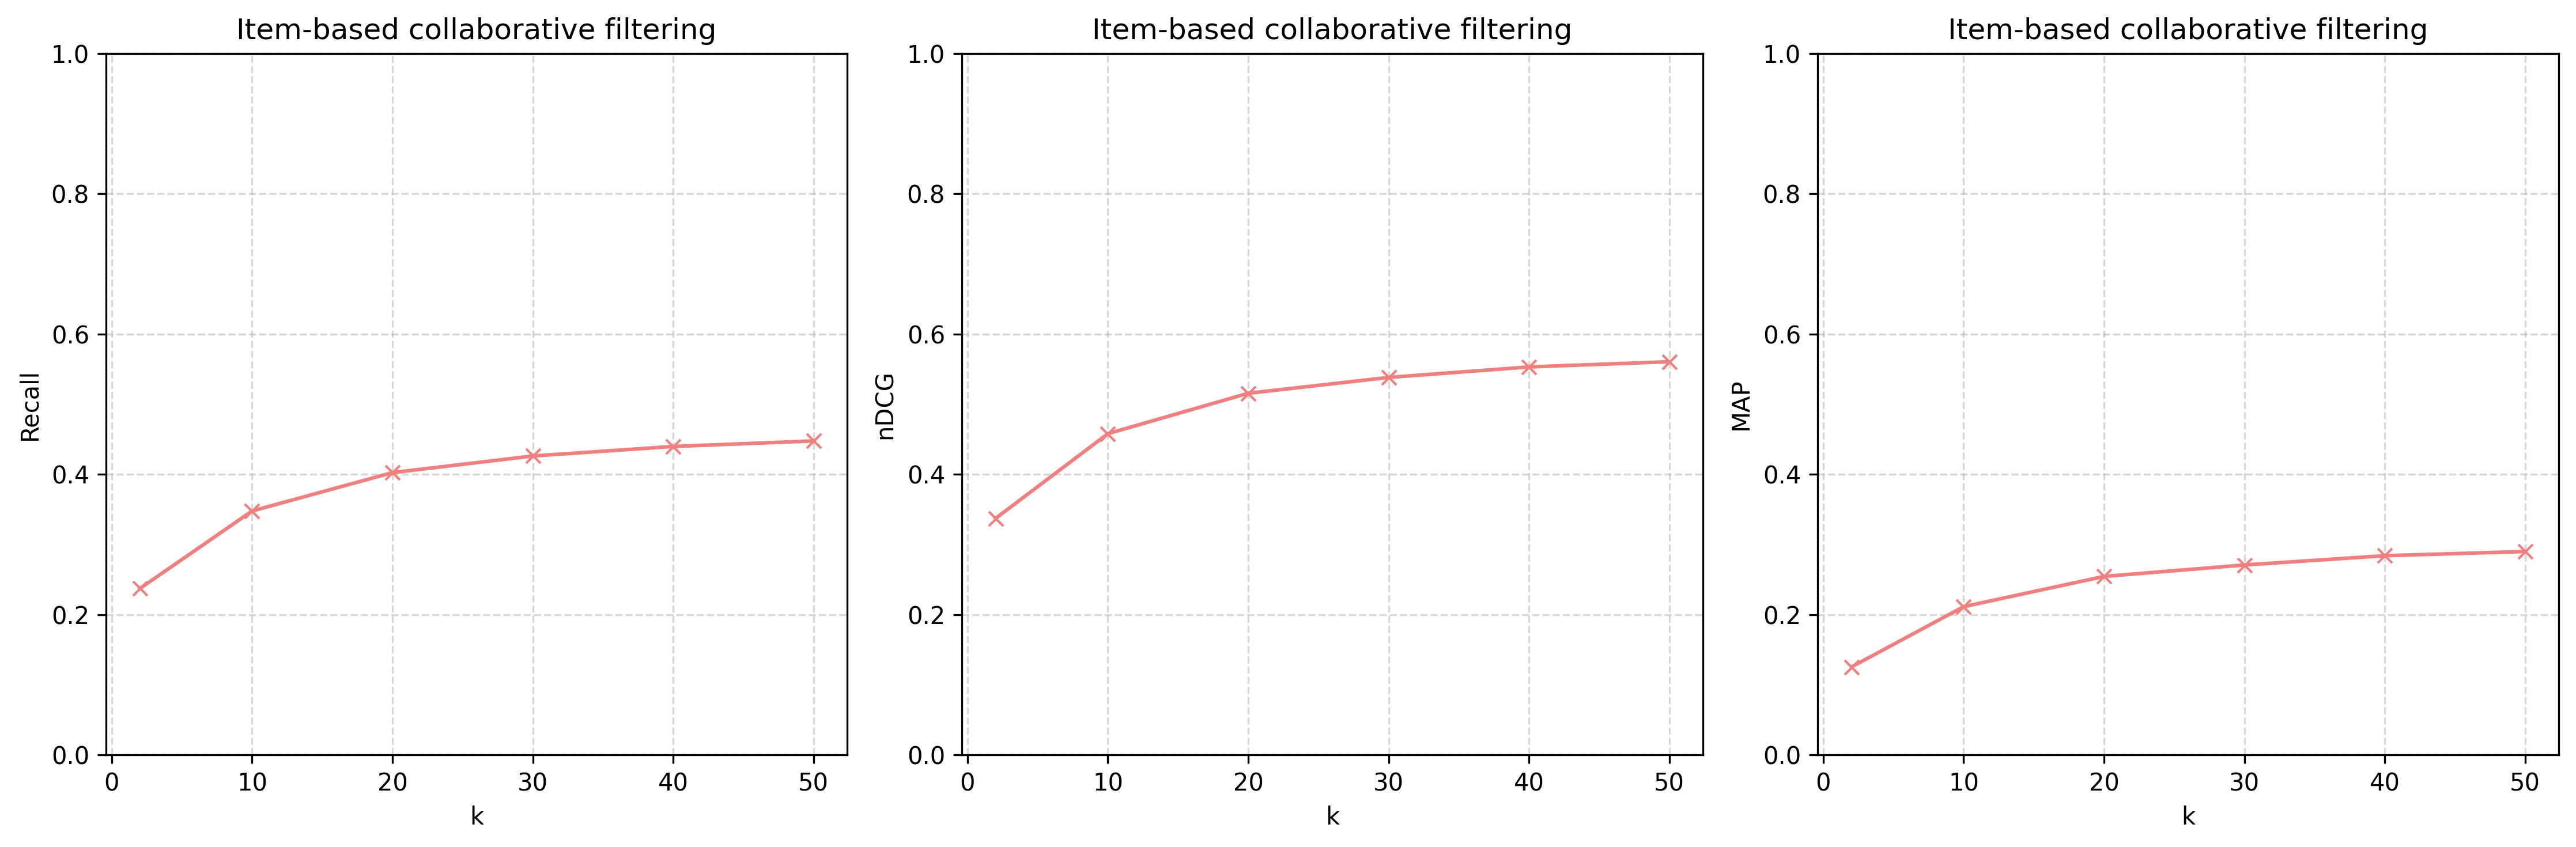

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

axes[0].plot(k_values, Recall_values, marker='x', color='lightcoral')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_values, nDCG_values, marker='x', color='lightcoral')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('nDCG')
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(k_values, MAP_values, marker='x', color='lightcoral')
axes[2].set_title('Item-based collaborative filtering')
axes[2].set_xlabel('k')
axes[2].set_ylabel('MAP')
axes[2].set_ylim(0, 1)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('item-based-rec-list-sens.jpeg')
plt.show()

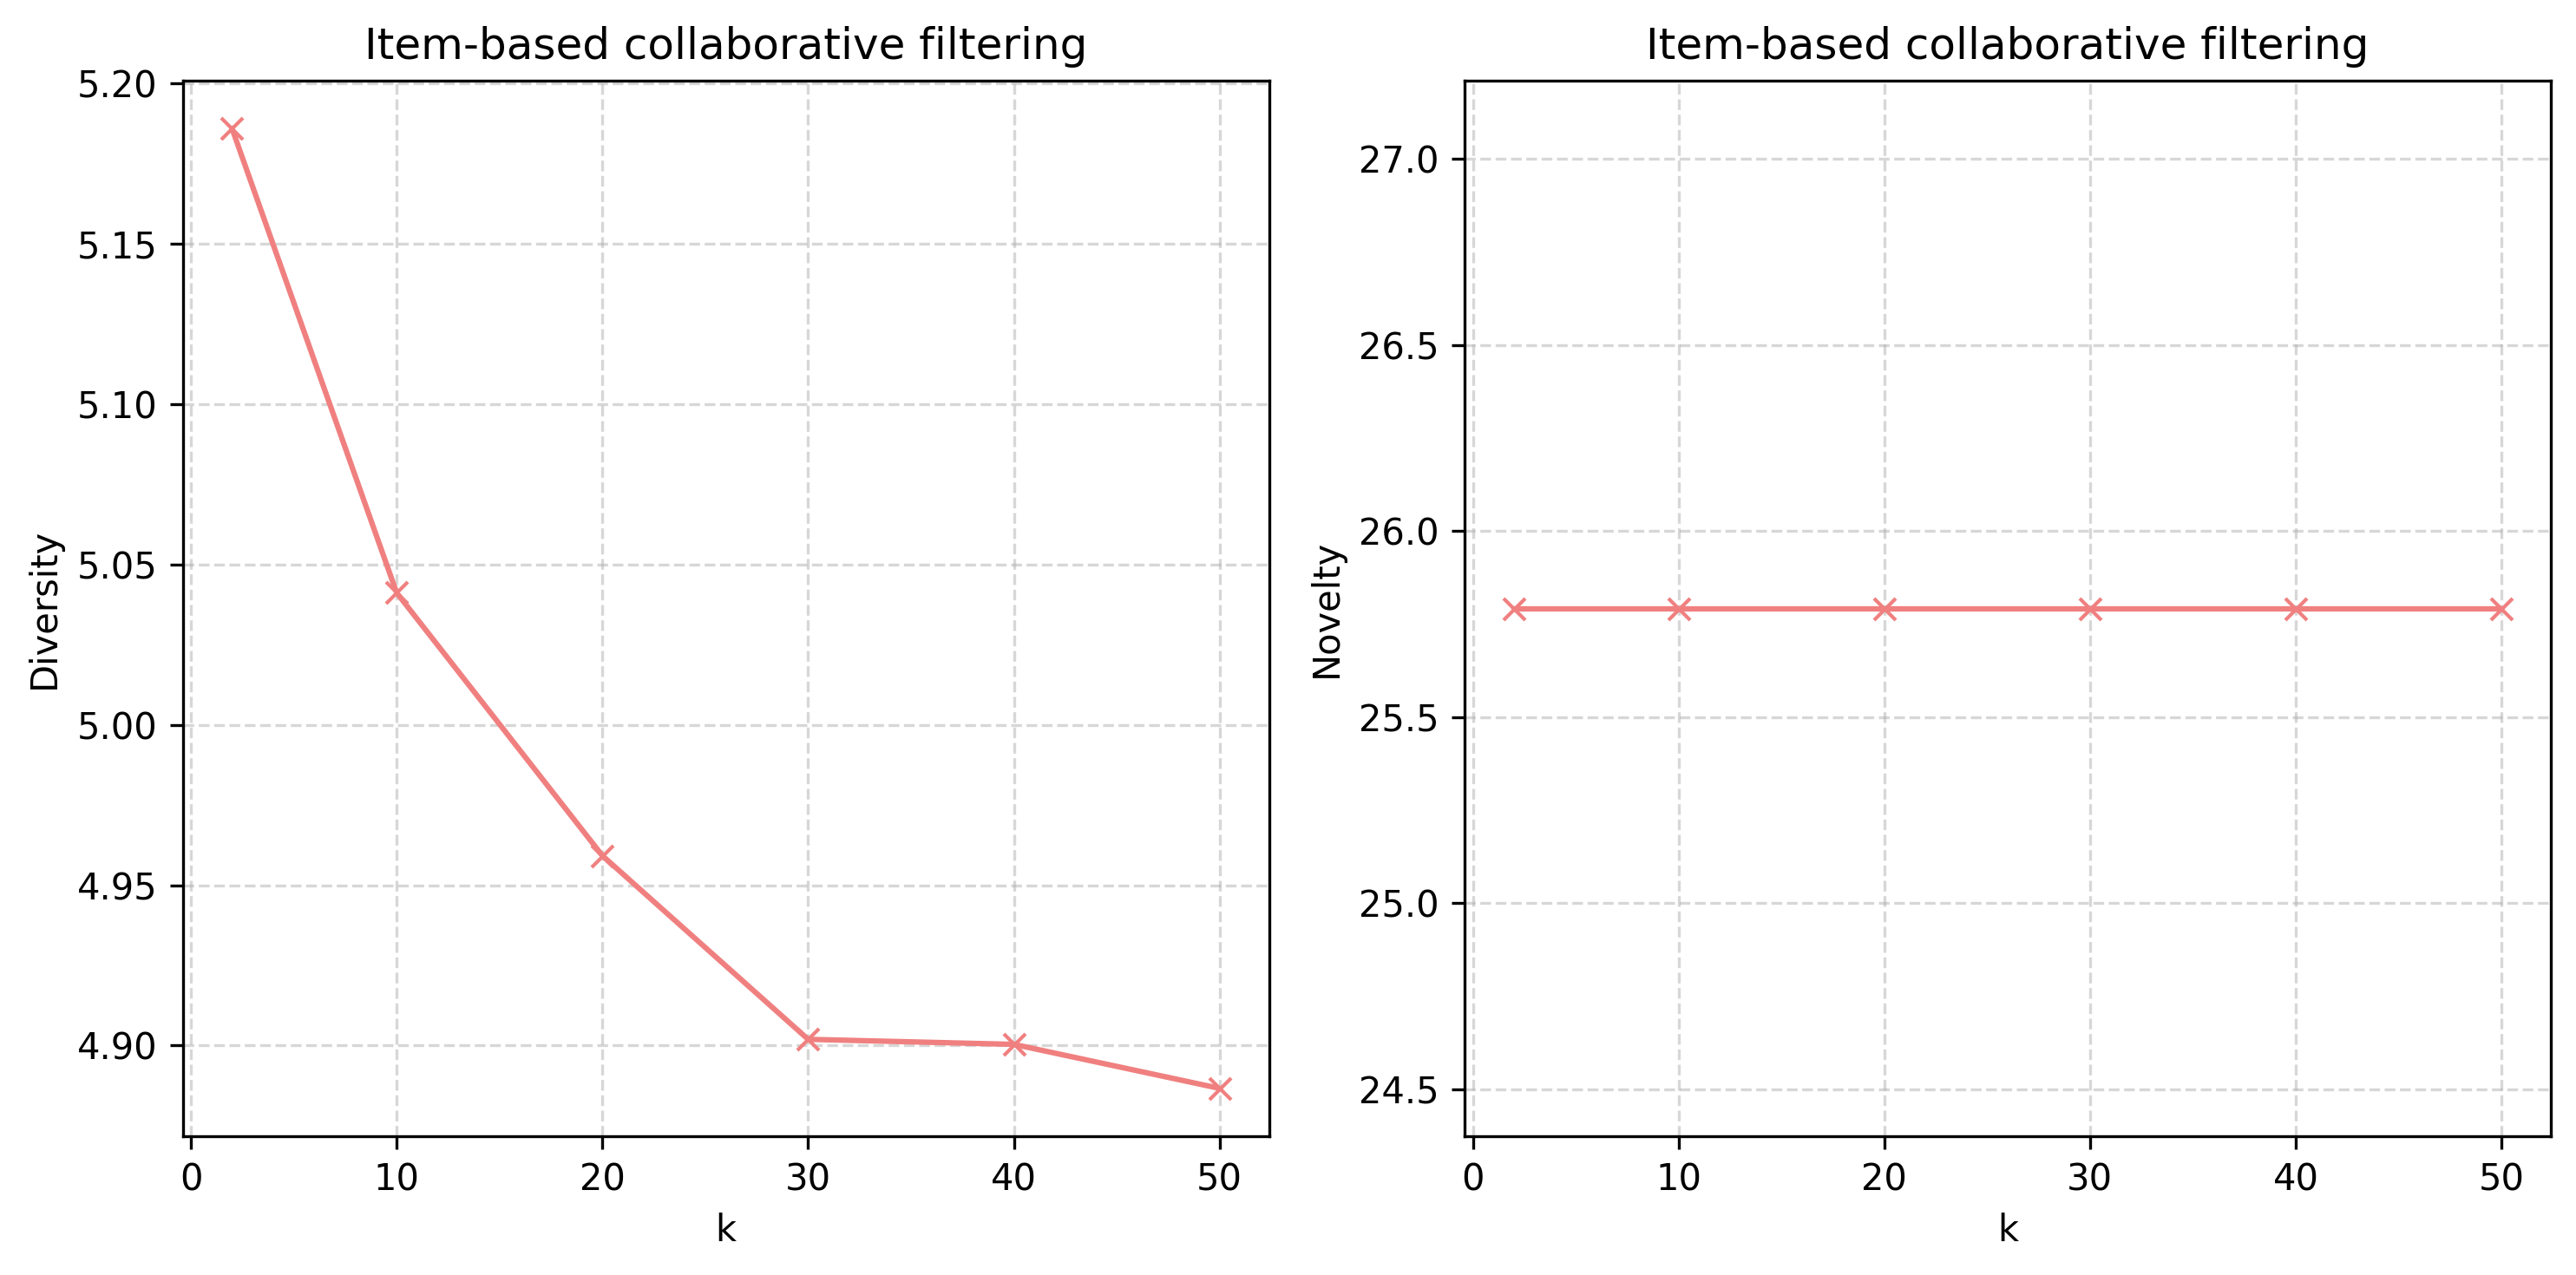

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

axes[0].plot(k_values, diversity_values, marker='x', color='lightcoral')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Diversity')
#axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(k_values, self_info_values, marker='x', color='lightcoral')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Novelty')
#axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('item-based-rec-list-div-novelty.jpeg')
plt.show()

## 2.4 FunkSVD

In [40]:
from surprise.prediction_algorithms.matrix_factorization import SVD

n_factors = [3, 25, 50, 75, 100]
testset = validation_data.build_testset()

Recall_values = []
nDCG_values = []
MAP_values = []
diversity_values = []
self_info_values = []

for factor in n_factors:
  svd_model = SVD(n_factors=factor, n_epochs=20)
  # Se entrena con set de entrenamiento
  svd_model.fit(train_data)
  # Se evalua con set de validacion
  predictions = svd_model.test(testset)
  top_n = get_top_n(predictions, n=N)

  recomendaciones_svd = {}
  for uid, user_ratings in top_n.items():
    # Extraemos solo el item_id (la posición 0 de la tupla) y lo pasamos a entero
    recomendaciones_svd[int(uid)] = [int(iid) for (iid, est) in user_ratings]

  Recall_values.append(recall_at_k(recomendaciones_svd, ground_truth, N))
  nDCG_values.append(ndcg_at_k(recomendaciones_svd, ground_truth, N))
  MAP_values.append(map_at_k(recomendaciones_svd, ground_truth, N))
  diversity_values.append(cant_estilos_distintos(recomendaciones_svd, yahoo_artists))
  self_info_values.append(self_information(recomendaciones_svd, yahoo_train))

max_rec_list_funk_svd = max(np.array(Recall_values))
max_rec_list_ndcg_funk_svd = max(np.array(nDCG_values))
max_rec_list_map_funk_svd = max(np.array(MAP_values))
max_rec_list_diversity_funk_svd = max(np.array(diversity_values))
max_rec_list_novelty_funk_svd = max(np.array(self_info_values))

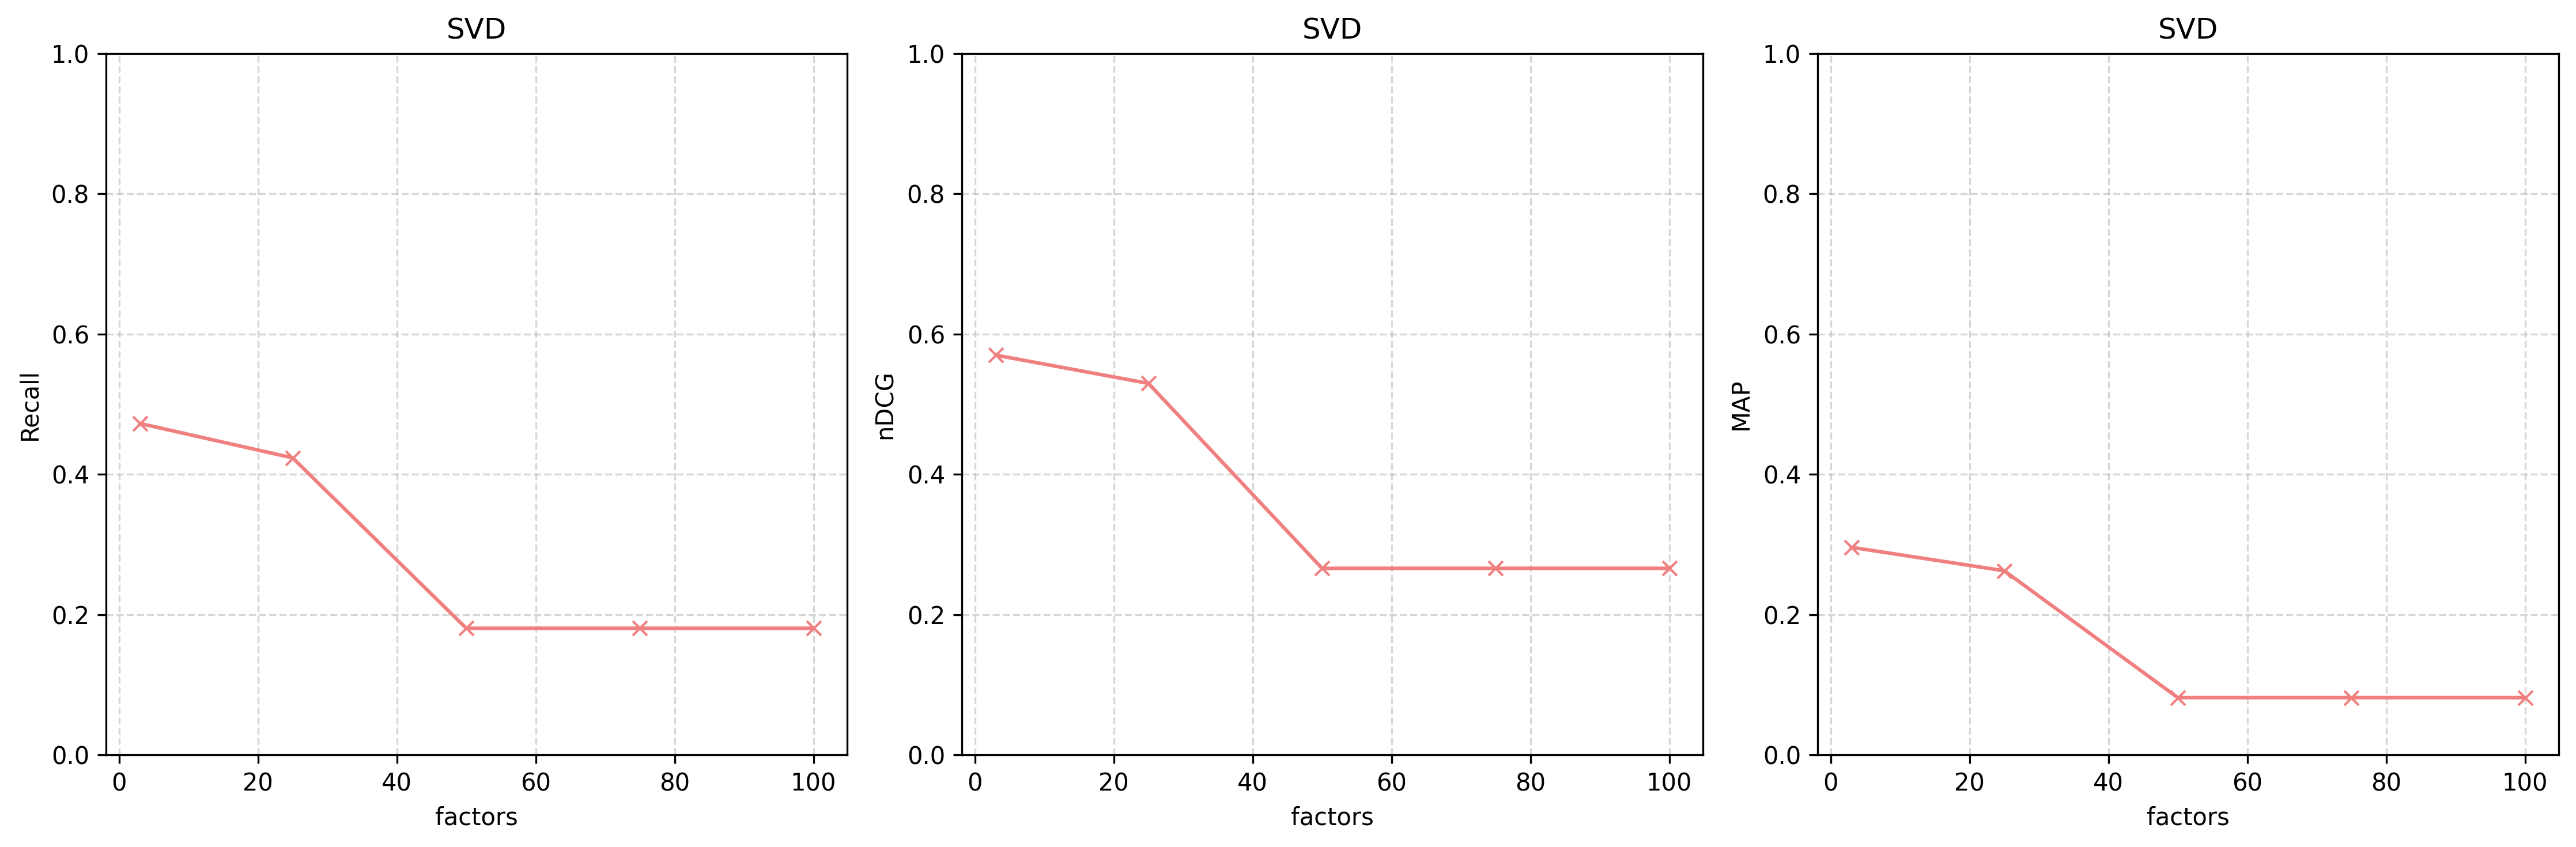

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

axes[0].plot(n_factors, Recall_values, marker='x', color='lightcoral')
axes[0].set_title('SVD')
axes[0].set_xlabel('factors')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.5)


axes[1].plot(n_factors, nDCG_values, marker='x', color='lightcoral')
axes[1].set_title('SVD')
axes[1].set_xlabel('factors')
axes[1].set_ylabel('nDCG')
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].plot(n_factors, MAP_values, marker='x', color='lightcoral')
axes[2].set_title('SVD')
axes[2].set_xlabel('factors')
axes[2].set_ylabel('MAP')
axes[2].set_ylim(0, 1)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('funk-svd-rec-list-sens.jpeg')
plt.show()

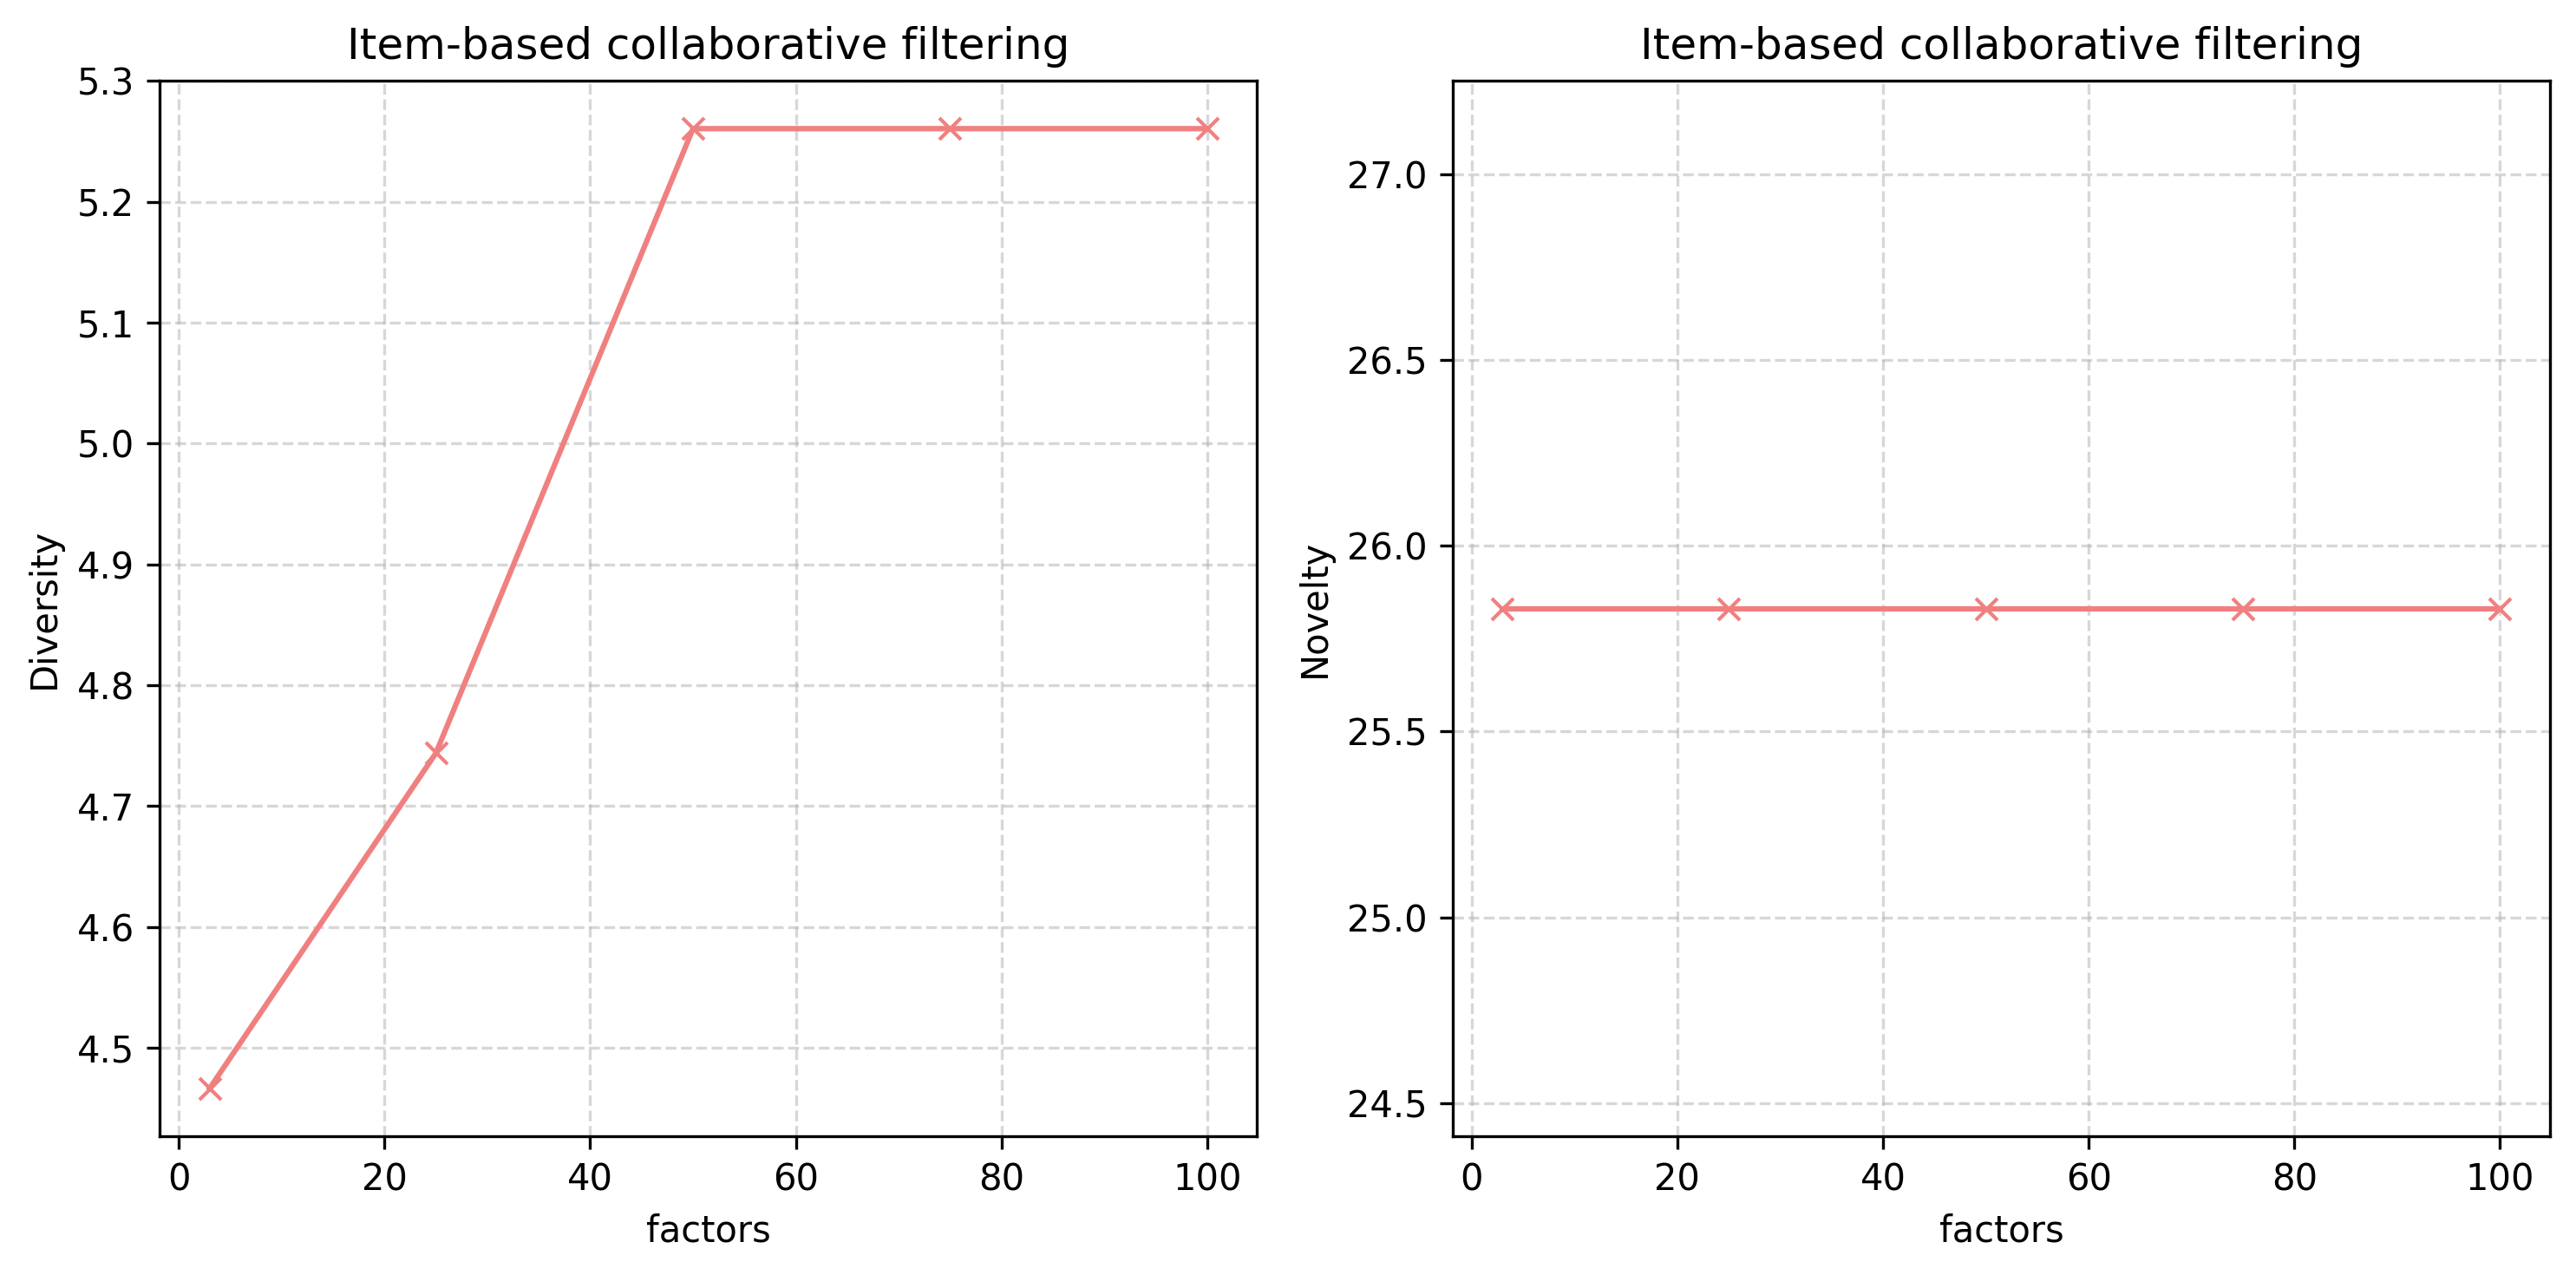

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

axes[0].plot(n_factors, diversity_values, marker='x', color='lightcoral')
axes[0].set_title('Item-based collaborative filtering')
axes[0].set_xlabel('factors')
axes[0].set_ylabel('Diversity')
#axes[0].set_ylim(0, 1)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(n_factors, self_info_values, marker='x', color='lightcoral')
axes[1].set_title('Item-based collaborative filtering')
axes[1].set_xlabel('factors')
axes[1].set_ylabel('Novelty')
#axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('funk-svd-rec-list-div-novelty.jpeg')
plt.show()

## Tablas

In [54]:
print('--------- TABLA 1 YAHOO ---------              RMSE                      MAE          ')

print(f'User based collaborative filtering: {min_rmse_user_based_cf}, {min_mae_user_based_cf}')
print(f'Item based collaborative filtering: {min_rmse_item_based_cf}, {min_mae_item_based_cf}')
print(f'FunkSVD:                            {min_rmse_funk_svd_cf}, {min_mae_funk_svd_cf}')

print('--------- TABLA 1 YAHOO: ---------')

print('--------- TABLA 2 YAHOO ---------              Recall                      nDCG                MAP        Diversity       Novelty')

print(f'Random:                              {tabla_random_recall}, {tabla_random_ndcg}, {tabla_random_map}, {tabla_random_div}, {tabla_random_nov}')
print(f'Most Popular:                        {tabla_most_popular_recall}, {tabla_most_popular_ndcg}, {tabla_most_popular_map}, {tabla_most_popular_div}, {tabla_most_popular_nov}')
print(f'Item based collaborative filtering:  {max_rec_list_item_based_cf}, {max_rec_list_ndcg_item_based_cf}, {max_rec_list_map_item_based_cf}, {max_rec_list_diversity_item_based_cf}, {max_rec_list_novelty_item_based_cf}')
print(f'FunkSVD:                             {max_rec_list_funk_svd}, {max_rec_list_ndcg_funk_svd}, {max_rec_list_map_funk_svd}, {max_rec_list_diversity_funk_svd}, {max_rec_list_novelty_funk_svd}')

print('--------- TABLA 2 YAHOO: ---------')

--------- TABLA 1 YAHOO ---------              RMSE                      MAE          
User based collaborative filtering: 26.343636279407647, 17.259951196639474
Item based collaborative filtering: 21.793159535011508, 12.388048350167123
FunkSVD:                            20.78189025396518, 12.896423469233774
--------- TABLA 1 YAHOO: ---------
--------- TABLA 2 YAHOO ---------              Recall                      nDCG                MAP        Diversity       Novelty
Random:                              0.004418989089627368, 0.0067858827546337435, 0.0013109336266690335, 5.417418595527658, 25.79942983448129
Most Popular:                        0.025243494863023838, 0.025265975770330573, 0.006978302880287537, 2.5205963122793253, 25.792142575075186
Item based collaborative filtering:  0.4476692460143474, 0.5606341534230416, 0.29000896791244685, 5.18595527657905, 25.792142575075186
FunkSVD:                             0.4723630829162512, 0.5700301824461889, 0.2959791851699708, 5.260494